In [33]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from tqdm.notebook import tqdm

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.8.0+cpu


## Access Dataset

In [34]:
DATA_ROOT = Path("../Bone_Fracture_Binary_Classification")

# Verify structure
for split in ["train", "val", "test"]:
    split_path = DATA_ROOT / split
    if split_path.exists():
        classes = [d.name for d in split_path.iterdir() if d.is_dir()]
        counts  = {c: len(list((split_path / c).glob("*.*"))) for c in classes}
        print(f"{split:5s}: {counts}")

train: {'fractured': 4606, 'not fractured': 4640}
val  : {'fractured': 337, 'not fractured': 492}
test : {'fractured': 238, 'not fractured': 268}


## Load and transform data

In [35]:
IMG_SIZE   = 224
BATCH_SIZE = 32

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = datasets.ImageFolder(DATA_ROOT / "train", transform=train_transforms)
val_dataset   = datasets.ImageFolder(DATA_ROOT / "val",   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(DATA_ROOT / "test",  transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Classes      : {CLASS_NAMES}")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples  : {len(val_dataset)}")
print(f"Test samples : {len(test_dataset)}")

Classes      : ['fractured', 'not fractured']
Train samples: 9246
Val samples  : 829
Test samples : 506


## EDA

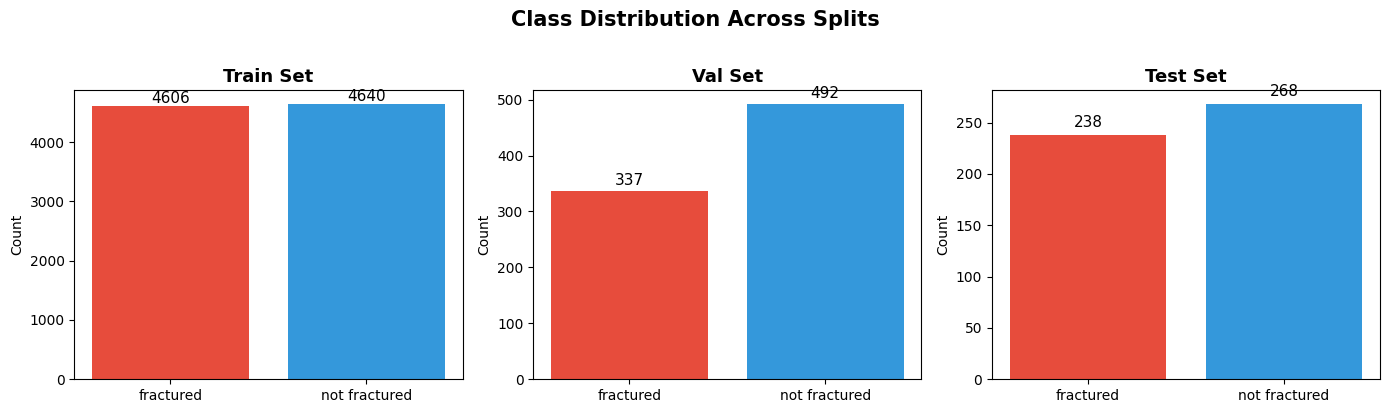

In [36]:
# Class distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette = ["#E74C3C", "#3498DB"]

for ax, split, ds in zip(axes, ["Train", "Val", "Test"],
                                [train_dataset, val_dataset, test_dataset]):
    counts = Counter(ds.targets)
    labels = [CLASS_NAMES[k] for k in sorted(counts)]
    values = [counts[k] for k in sorted(counts)]
    bars   = ax.bar(labels, values, color=palette)
    ax.set_title(f"{split} Set", fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(val), ha="center", va="bottom", fontsize=11)

plt.suptitle("Class Distribution Across Splits", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

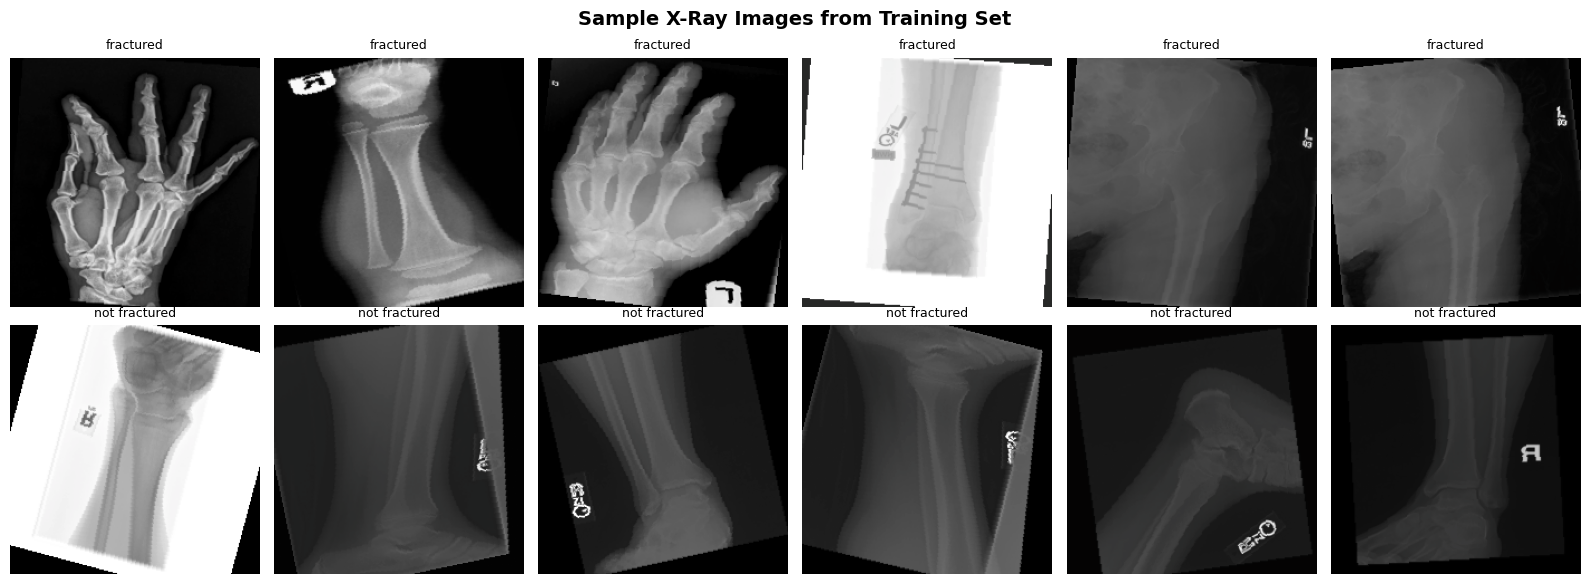

In [37]:
# Sample images
def denormalize(tensor, mean=MEAN, std=STD):
    t = tensor.clone()
    for c, m, s in zip(range(3), mean, std):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle("Sample X-Ray Images from Training Set", fontsize=14, fontweight="bold")

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    indices = [i for i, t in enumerate(train_dataset.targets) if t == cls_idx][:6]
    for col, idx in enumerate(indices):
        img, _ = train_dataset[idx]
        axes[cls_idx][col].imshow(denormalize(img).permute(1, 2, 0))
        axes[cls_idx][col].set_title(cls_name, fontsize=9)
        axes[cls_idx][col].axis("off")

plt.tight_layout()
plt.show()

## Create CNN Architecture

In [38]:
class FractureCNN(nn.Module):
    # 4 convolutional blocks (Conv, BN, ReLU, Conv, BN, ReLU, MaxPool, Dropout)
    # Adaptive average pool, flatten, 3-layer FC head


    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 224 to 112
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.1),

            # Block 2: 112 to 56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.15),

            # Block 3: 56 to 28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),

            # Block 4: 28 to 14
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.pool = nn.AdaptiveAvgPool2d((4, 4)) 
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


model = FractureCNN(num_classes=NUM_CLASSES).to(device)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:")
print(model)

Total parameters    : 2,747,170
Trainable parameters: 2,747,170

Model architecture:
FractureCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13):

## Training

In [39]:
def train_model(model, train_loader, val_loader, num_epochs=20, lr=1e-3, weight_decay=1e-4):
    # Uses CrossEntropyLoss, Adam optimiser, ReduceLROnPlateau scheduler, best-model checkpoint saved by val accuracy
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, num_epochs + 1):
        epoch_start = time.time()

        # Train
        model.train()
        run_loss, run_correct, run_total = 0.0, 0, 0

        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [train]", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            run_loss    += loss.item() * imgs.size(0)
            preds        = outputs.argmax(dim=1)
            run_correct += (preds == labels).sum().item()
            run_total   += imgs.size(0)

        train_loss = run_loss / run_total
        train_acc  = run_correct / run_total

        # Validate 
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs      = model(imgs)
                loss         = criterion(outputs, labels)
                val_loss    += loss.item() * imgs.size(0)
                preds        = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total   += imgs.size(0)

        val_loss /= val_total
        val_acc   = val_correct / val_total

        scheduler.step(val_acc)
        current_lr = optimizer.param_groups[0]["lr"]

        # Checkpoint best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            checkpoint_marker = "  ✅ best"
        else:
            checkpoint_marker = ""

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        elapsed = time.time() - epoch_start
        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | "
            f"LR: {current_lr:.2e} | "
            f"Time: {elapsed:.1f}s"
            f"{checkpoint_marker}"
        )

    print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
    model.load_state_dict(best_weights)
    return model, history

In [ ]:
from PIL import Image, ImageFile
from pathlib import Path

ImageFile.LOAD_TRUNCATED_IMAGES = False  

bad_files = []
for img_path in DATA_ROOT.rglob("*.*"):
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]:
        try:
            with Image.open(img_path) as img:
                img.load()  
        except Exception as e:
            bad_files.append((img_path, str(e)))

for path, _ in bad_files:
    path.unlink()

Found 18 corrupted file(s):
  ..\Bone_Fracture_Binary_Classification\test\not fractured\IMG0004134.jpg  —  image file is truncated (1 bytes not processed)
  ..\Bone_Fracture_Binary_Classification\test\not fractured\IMG0004143.jpg  —  image file is truncated (10 bytes not processed)
  ..\Bone_Fracture_Binary_Classification\test\not fractured\IMG0004148.jpg  —  image file is truncated (14 bytes not processed)
  ..\Bone_Fracture_Binary_Classification\test\not fractured\IMG0004149.jpg  —  image file is truncated (33 bytes not processed)
  ..\Bone_Fracture_Binary_Classification\test\not fractured\IMG0004308.jpg  —  image file is truncated (40 bytes not processed)
  ..\Bone_Fracture_Binary_Classification\test\not fractured\IMG0004347.jpg  —  image file is truncated (40 bytes not processed)
  ..\Bone_Fracture_Binary_Classification\train\not fractured\IMG0004134.jpg  —  image file is truncated (1 bytes not processed)
  ..\Bone_Fracture_Binary_Classification\train\not fractured\IMG0004143.jpg  

In [40]:
NUM_EPOCHS = 20   

print("=" * 60)
print("Training Custom CNN")
print("=" * 60)

model, history = train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=NUM_EPOCHS,
    lr=1e-3,
    weight_decay=1e-4
)

Training Custom CNN


Epoch 1/20 [train]:   0%|          | 0/289 [00:00<?, ?it/s]

OSError: Caught OSError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "c:\Users\jacki\anaconda3\envs\py310\lib\site-packages\torch\utils\data\_utils\worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "c:\Users\jacki\anaconda3\envs\py310\lib\site-packages\torch\utils\data\_utils\fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "c:\Users\jacki\anaconda3\envs\py310\lib\site-packages\torch\utils\data\_utils\fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "c:\Users\jacki\anaconda3\envs\py310\lib\site-packages\torchvision\datasets\folder.py", line 245, in __getitem__
    sample = self.loader(path)
  File "c:\Users\jacki\anaconda3\envs\py310\lib\site-packages\torchvision\datasets\folder.py", line 284, in default_loader
    return pil_loader(path)
  File "c:\Users\jacki\anaconda3\envs\py3

## Training Curves

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)
color  = "#E74C3C"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs, history["train_loss"], linestyle="--", color=color, alpha=0.6, label="Train")
axes[0].plot(epochs, history["val_loss"],   linestyle="-",  color=color, linewidth=2, label="Val")
axes[0].set_title("Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

# Accuracy
axes[1].plot(epochs, history["train_acc"], linestyle="--", color=color, alpha=0.6, label="Train")
axes[1].plot(epochs, history["val_acc"],   linestyle="-",  color=color, linewidth=2, label="Val")

# Mark best val acc epoch
best_epoch = history["val_acc"].index(max(history["val_acc"])) + 1
best_acc   = max(history["val_acc"])
axes[1].axvline(best_epoch, color="gray", linestyle=":", alpha=0.8)
axes[1].annotate(
    f"Best: {best_acc:.3f}\n(epoch {best_epoch})",
    xy=(best_epoch, best_acc),
    xytext=(best_epoch + 1, best_acc - 0.05),
    arrowprops=dict(arrowstyle="->", color="gray"),
    fontsize=9, color="gray"
)
axes[1].set_title("Accuracy", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Custom CNN — Training Curves", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

NameError: name 'history' is not defined

## Evaluate on test

In [ ]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs    = imgs.to(device)
        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        preds   = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

## Create Confusion Matrix

In [ ]:
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

NameError: name 'all_labels' is not defined

## ROC Curve

In [ ]:
POSITIVE_CLASS = CLASS_NAMES.index("fractured") if "fractured" in CLASS_NAMES else 0

y_score        = all_probs[:, POSITIVE_CLASS]
y_true_binary  = (all_labels == POSITIVE_CLASS).astype(int)
fpr, tpr, _    = roc_curve(y_true_binary, y_score)
auc            = roc_auc_score(y_true_binary, y_score)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="#E74C3C", lw=2, label=f"Custom CNN (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC: {auc:.4f}")

## View Misclassifications

In [ ]:
wrong_idx = np.where(all_preds != all_labels)[0][:12]

if len(wrong_idx) == 0:
    print("No misclassifications on the test set!")
else:
    cols = 6
    rows = (len(wrong_idx) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.8))
    axes = axes.flatten()

    for ax, idx in zip(axes, wrong_idx):
        img, _ = test_dataset[idx]
        ax.imshow(denormalize(img).permute(1, 2, 0))
        true_lbl = CLASS_NAMES[all_labels[idx]]
        pred_lbl = CLASS_NAMES[all_preds[idx]]
        ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}", fontsize=8, color="red")
        ax.axis("off")

    for ax in axes[len(wrong_idx):]:
        ax.axis("off")

    plt.suptitle("Misclassified Samples", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"Total misclassified: {len(wrong_idx)} / {len(test_dataset)}")

## Save Model for Future Use

In [ ]:
os.makedirs("checkpoints", exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names":      CLASS_NAMES,
    "history":          history,
    "test_accuracy":    float(test_acc),
}, "checkpoints/custom_cnn_best.pth")

print("Model saved to ./checkpoints/custom_cnn_best.pth")

## Inference on Single Image

In [ ]:
from PIL import Image

def predict_single(model, image_path):
    # Run inference on one X-ray image and display result
    img    = Image.open(image_path).convert("RGB")
    tensor = val_test_transforms(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1).squeeze().cpu().numpy()
        pred   = probs.argmax()

    label_color = "green" if CLASS_NAMES[pred] == "non-fractured" else "red"

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img, cmap="gray")
    axes[0].axis("off")
    axes[0].set_title(
        f"Prediction: {CLASS_NAMES[pred]}\nConfidence: {probs[pred]:.2%}",
        fontsize=12, fontweight="bold", color=label_color
    )
    axes[1].barh(CLASS_NAMES, probs, color=["#E74C3C", "#2ECC71"])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Probability")
    axes[1].set_title("Class Probabilities")
    axes[1].grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return CLASS_NAMES[pred], probs


# Grab the first test image
sample_path, sample_label = test_dataset.samples[0]
print(f"Image : {sample_path}")
print(f"True label: {CLASS_NAMES[sample_label]}")
predict_single(model, sample_path)